In [ ]:
import pylbsr.notebooks
import pylbsr.misc

import torch
import yaml
from functools import partial
from pathlib import Path
from dotmap import DotMap
from tqdm import tqdm

from parnet_demo_utils import (
    filter_min_read_count,
    torch_sparse_to_dense,
)

In [28]:
_notebook_name = "00_prepare_globalclip_dataset.ipynb"
_notebook_path = f"notebooks/globalclip-head/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)
logger = pylbsr.misc.init_logger(_notebook_name)
PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

[15:00:48] INFO - Project directory: /mnt/storage1/workspace/lhofer/parnet--globalclip-head


⏱ 0.01 s (00:00:00)


In [29]:
# ── Quality filter ─────────────────────────────────────────────────────────────
PARAMS_MIN_READ_COUNT: int = 3  # keep window if globalCLIP signal reaches this count anywhere
PARAMS_MAX_TOTAL_SIGNAL: int = 1000


⏱ 0.00 s (00:00:00)


In [30]:
_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())

FILEPATHS = DotMap()
FILEPATHS["data_in"]  = Path(_fp_cfg["global_clip"]["data_lysate_noNHS"])
FILEPATHS["data_out"] = (
    PROJECT_DIR / "results" / "globalclip-head" / "datasets"
    / f"globalclip_lysate_noNHS.minreads{PARAMS_MIN_READ_COUNT}.maxsignal{PARAMS_MAX_TOTAL_SIGNAL}.pt"
)
logger.info(f"Input:  {FILEPATHS.data_in}")
logger.info(f"Output: {FILEPATHS.data_out}")

[15:00:49] INFO - Input:  /mnt/storage1/ml4rg26-deconvgclip/provided_data/600nt_globalCLIP_synchronized_datasets/globalclip_lysate_noNHS_600bp_signalfiltered.pt
[15:00:49] INFO - Output: /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/datasets/globalclip_lysate_noNHS.minreads3.maxsignal1000.pt


⏱ 0.01 s (00:00:00)


In [31]:
### LOAD RAW DATA

logger.info(f"Loading (mmap) {FILEPATHS.data_in} ...")
data = torch.load(FILEPATHS.data_in, mmap=True, weights_only=False)
logger.info(f"Source splits: { {k: len(v) for k, v in data.items()} }")

[15:00:49] INFO - Loading (mmap) /mnt/storage1/ml4rg26-deconvgclip/provided_data/600nt_globalCLIP_synchronized_datasets/globalclip_lysate_noNHS_600bp_signalfiltered.pt ...
metadata:   0%|          | 0/6 [17:30<?, ?it/s]
[15:01:00] INFO - Source splits: {'valid': 7361, 'train': 39052, 'test': 4946, 'metadata': 6}


⏱ 11.33 s (00:00:11)


In [32]:
_quality_filter = partial(
    filter_min_read_count,
    min_read_count=PARAMS_MIN_READ_COUNT,
    tasks=["globalCLIP"],
    track_indices=[0],
)

def _max_signal_filter(element, max_total_signal=PARAMS_MAX_TOTAL_SIGNAL, task="globalCLIP"):
    dense = torch_sparse_to_dense(element["outputs"][task])
    return dense.sum().item() <= max_total_signal

output_splits = {}
for split_name, samples in data.items():
    if not isinstance(samples, list):
        logger.info(f"Skipping non-list split: {split_name}")
        continue
    _filtered = [
        s for s in tqdm(samples, desc=split_name)
        if _quality_filter(s) and _max_signal_filter(s) # apply both filters
    ]
    logger.info(f"[{split_name}] {len(samples):,} → {len(_filtered):,} windows after filter")
    output_splits[split_name] = _filtered

valid: 100%|██████████| 7361/7361 [00:00<00:00, 26468.24it/s]
[15:01:01] INFO - [valid] 7,361 → 7,266 windows after filter
train: 100%|██████████| 39052/39052 [00:01<00:00, 26125.40it/s]
[15:01:02] INFO - [train] 39,052 → 38,695 windows after filter
test: 100%|██████████| 4946/4946 [00:00<00:00, 25955.39it/s]
[15:01:02] INFO - [test] 4,946 → 4,896 windows after filter
[15:01:02] INFO - Skipping non-list split: metadata


⏱ 2.26 s (00:00:02)


Computing signals...


100%|██████████| 38695/38695 [00:00<00:00, 70843.73it/s]



                                        Raw     Filtered
N windows                            39,052       38,695
Mean                                  165.0         75.8
Median                                 44.0         43.0
99th percentile                       943.5        594.0
Max                                525738.0       1000.0
Windows >1000                           357            0


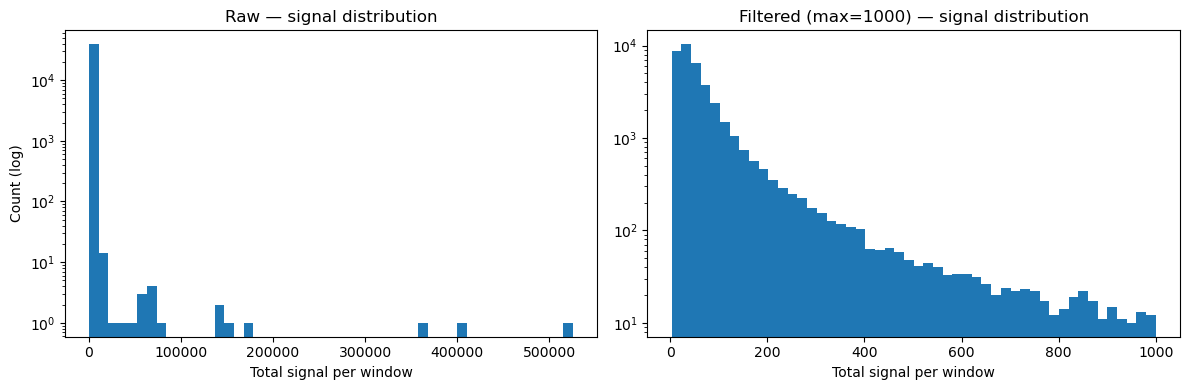

⏱ 1.77 s (00:00:01)


In [34]:
import numpy as np
import matplotlib.pyplot as plt

def get_signals(splits_dict, split="train"):
    signals = []
    for s in tqdm(splits_dict[split]):
        dense = torch_sparse_to_dense(s["outputs"]["globalCLIP"])
        signals.append(dense.sum().item())
    return np.array(signals)

print("Computing signals...")
signals_raw      = get_signals(data, "train")
signals_filtered = get_signals(output_splits, "train")

print(f"\n{'':30s} {'Raw':>12s} {'Filtered':>12s}")
print(f"{'N windows':30s} {len(signals_raw):>12,} {len(signals_filtered):>12,}")
print(f"{'Mean':30s} {np.mean(signals_raw):>12.1f} {np.mean(signals_filtered):>12.1f}")
print(f"{'Median':30s} {np.median(signals_raw):>12.1f} {np.median(signals_filtered):>12.1f}")
print(f"{'99th percentile':30s} {np.percentile(signals_raw, 99):>12.1f} {np.percentile(signals_filtered, 99):>12.1f}")
print(f"{'Max':30s} {np.max(signals_raw):>12.1f} {np.max(signals_filtered):>12.1f}")
print(f"{'Windows >1000':30s} {sum(signals_raw > 1000):>12,} {sum(signals_filtered > 1000):>12,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(signals_raw, bins=50, log=True)
axes[0].set_title('Raw — signal distribution')
axes[0].set_xlabel('Total signal per window')
axes[0].set_ylabel('Count (log)')

axes[1].hist(signals_filtered, bins=50, log=True)
axes[1].set_title('Filtered (max=1000) — signal distribution')
axes[1].set_xlabel('Total signal per window')

plt.tight_layout()
plt.show()

In [35]:
### SAVE FILTERED DATA

FILEPATHS["data_out"].parent.mkdir(parents=True, exist_ok=True)
logger.info(f"Saving filtered dataset → {FILEPATHS.data_out} ...")
torch.save(output_splits, FILEPATHS.data_out)
logger.info(f"Saved ({FILEPATHS.data_out.stat().st_size / 1e6:.0f} MB)")

[15:09:23] INFO - Saving filtered dataset → /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/globalclip-head/datasets/globalclip_lysate_noNHS.minreads3.maxsignal1000.pt ...
[15:09:33] INFO - Saved (181 MB)


⏱ 9.77 s (00:00:09)
